In [16]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("AmazonAnalytics")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")!
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/13 00:18:43 WARN Utils: Your hostname, Shreyashs-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.0.0.2 instead (on interface en0)
26/06/13 00:18:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/13 00:18:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
parquet_path = "/Volumes/T7 Shield/data-project/parquet/amazon_multicategory_v1.parquet"

df = spark.read.parquet(parquet_path)

In [3]:
print(df.count())
df.printSchema()

29365829
root
 |-- parent_asin: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- review_title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- store: string (nullable = true)
 |-- price: double (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- final_category: string (nullable = true)
 |-- sub_category: string (nullable = true)
 |-- review_length: integer (nullable = true)
 |-- sentiment: string (nullable = true)
 |-- clean_text: string (nullable = true)
 |-- review_datetime: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- review_year: integer (nullable = true)



<h4>Twenty-nine million, three hundred sixty-five thousand, eight hundred twenty-nine

In [4]:
df.select("final_category").distinct().show(truncate=False)

[Stage 4:=======================================================> (93 + 3) / 96]

+-------------------+
|final_category     |
+-------------------+
|Sports & Outdoors  |
|Video Games        |
|Appliances         |
|Musical Instruments|
+-------------------+



In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("AmazonAnalytics")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    # --- THIS IS THE MAGIC FIX ---
    # This forces Spark to use your external drive for all temporary processing
    .config("spark.local.dir", "/Volumes/T7 Shield/spark-temp") 
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/13 07:44:07 WARN Utils: Your hostname, Shreyashs-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.0.0.2 instead (on interface en0)
26/06/13 07:44:07 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/13 07:44:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/13 07:44:09 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


In [5]:
from pyspark.sql.functions import col

# 1. Define your exact categories
target_categories = [
    'Sports & Outdoors', 
    'Video Games', 
    'Appliances', 
    'Musical Instruments'
]

# 2. Create an empty list to hold our 4 perfectly sized chunks
sampled_dfs = []

# 3. Process ONE category at a time to save memory and disk space
for category in target_categories:
    print(f"Processing {category}...")
    
    # Isolate the single category
    cat_df = df.filter(col("final_category") == category)
    
    # .sample() grabs random rows WITHOUT causing a massive disk shuffle. 
    # We use fraction=0.5 (50% of the data) to ensure we have enough random rows 
    # to hit our 125,000 target, then we chop off exactly 125,000.
    sampled_cat = cat_df.sample(withReplacement=False, fraction=0.5, seed=42).limit(125000)
    
    # Add this small chunk to our list
    sampled_dfs.append(sampled_cat)

print("Stitching the chunks together...")

# 4. Combine the 4 tiny dataframes into one perfectly balanced dataframe
final_balanced_df = sampled_dfs[0]
for i in range(1, len(sampled_dfs)):
    final_balanced_df = final_balanced_df.union(sampled_dfs[i])

# 5. Verify the counts to ensure you got exactly 125,000 for each
print("Final Row Count per Category:")
final_balanced_df.groupBy("final_category").count().show()

# 6. Save directly to your T7 Shield
save_path = "/Volumes/T7 Shield/data-project/parquet/balanced_amazon_reviews_500k.parquet"
final_balanced_df.write.mode("overwrite").parquet(save_path)

print(f"Success! Parquet file saved to: {save_path}")

Processing Sports & Outdoors...
Processing Video Games...
Processing Appliances...
Processing Musical Instruments...
Stitching the chunks together...
Final Row Count per Category:


+-------------------+------+
|     final_category| count|
+-------------------+------+
|  Sports & Outdoors|125000|
|        Video Games|125000|
|         Appliances|125000|
|Musical Instruments|125000|
+-------------------+------+



[Stage 24:>                                                         (0 + 1) / 1]

Success! Parquet file saved to: /Volumes/T7 Shield/data-project/parquet/balanced_amazon_reviews_500k.parquet


In [6]:
import pandas as pd

# 1. Load the Parquet file we just created
file_path = "/Volumes/T7 Shield/data-project/parquet/balanced_amazon_reviews_500k.parquet"
print("Loading Parquet...")
df = pd.read_parquet(file_path)

# 2. Save it directly as a CSV
csv_path = "/Volumes/T7 Shield/data-project/parquet/balanced_amazon_reviews_500k.csv"
print("Saving as CSV...")
df.to_csv(csv_path, index=False)

print(f"Done! You can now open this CSV directly in Tableau: {csv_path}")

Loading Parquet...
Saving as CSV...
Done! You can now open this CSV directly in Tableau: /Volumes/T7 Shield/data-project/parquet/balanced_amazon_reviews_500k.csv


In [11]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 10.1 MB/s  0:00:00a 0:00:0136m0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 27.4 MB/s  0:00:007.2 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Load the balanced data
file_path = "/Volumes/T7 Shield/data-project/parquet/balanced_amazon_reviews_500k.parquet"
print("1. Loading data from T7 Shield...")
df = pd.read_parquet(file_path)

# 2. Clean out empty text rows (Models can't learn from blank reviews)
df = df.dropna(subset=['clean_text', 'sentiment'])

# 3. Split into Training Data (80%) and Testing Data (20%)
print("2. Splitting data into Train and Test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], 
    df['sentiment'], 
    test_size=0.2, 
    random_state=42
)

# 4. Convert Text to Numbers (TF-IDF)
print("3. Vectorizing text (Translating words to numbers)...")
# max_features=5000 keeps it blazing fast by only looking at the 5k most important words
vectorizer = TfidfVectorizer(max_features=5000) 
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 5. Train the Model
print("4. Training the Machine Learning Model...")
# n_jobs=-1 tells your Mac to use all available CPU cores to speed this up
model = LogisticRegression(max_iter=1000, n_jobs=-1) 
model.fit(X_train_vec, y_train)

# 6. Test the Model on the 20% it has never seen before
print("\n--- Model Accuracy Report ---")
predictions = model.predict(X_test_vec)
print(classification_report(y_test, predictions))

# 7. The Fun Part: Test it with a custom sentence!
print("\n--- Custom Review Test ---")
custom_review = ["The fret buzz on this acoustic guitar is terrible, completely unplayable out of the box."]
custom_vec = vectorizer.transform(custom_review)
custom_pred = model.predict(custom_vec)

print(f"Raw Text: '{custom_review[0]}'")
print(f"AI Prediction: {custom_pred[0]}")

1. Loading data from T7 Shield...
2. Splitting data into Train and Test sets...
3. Vectorizing text (Translating words to numbers)...
4. Training the Machine Learning Model...


/Volumes/T7 Shield/data-project/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



--- Model Accuracy Report ---
              precision    recall  f1-score   support

    Negative       0.75      0.72      0.74     15213
     Neutral       0.40      0.09      0.15      6456
    Positive       0.91      0.97      0.94     78331

    accuracy                           0.88    100000
   macro avg       0.69      0.59      0.61    100000
weighted avg       0.85      0.88      0.85    100000


--- Custom Review Test ---
Raw Text: 'The fret buzz on this acoustic guitar is terrible, completely unplayable out of the box.'
AI Prediction: Negative


In [14]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. LOAD THE DATA (This fixes the NameError!)
file_path = "/Volumes/T7 Shield/data-project/parquet/balanced_amazon_reviews_500k.parquet"
print("Loading data from T7 Shield...")
df_ml = pd.read_parquet(file_path)

# 2. Isolate the numerical features
# We drop rows with missing numbers so the math doesn't break
features = ['price', 'rating', 'review_length', 'helpful_vote']
df_cluster = df_ml.dropna(subset=features).copy()

X = df_cluster[features]

# 3. Scale the Data (CRUCIAL STEP)
# The scaler forces all metrics onto an equal playing field so price doesn't dominate rating.
print("Scaling the data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train the K-Means Model
print("Training AI to find 4 hidden clusters...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df_cluster['hidden_cluster'] = kmeans.fit_predict(X_scaled)

# 5. The Big Reveal: What did the AI find?
# We group by the new clusters to see the average stats of each group
cluster_summary = df_cluster.groupby('hidden_cluster')[features].mean().round(2)
cluster_summary['total_reviews'] = df_cluster['hidden_cluster'].value_counts()

print("\n--- The 4 Hidden Product Personas ---")
print(cluster_summary)

Loading data from T7 Shield...
Scaling the data...
Training AI to find 4 hidden clusters...

--- The 4 Hidden Product Personas ---
                 price  rating  review_length  helpful_vote  total_reviews
hidden_cluster                                                            
0               421.47    4.10        1488.70         10.20          10648
1                49.25    4.86         160.03          0.56         264338
2                52.94    1.79         239.15          1.12          68738
3               178.87    4.04        1878.77       1037.12             26


/var/folders/dj/04ynshgn207cy981xd7ymn340000gn/T/ipykernel_37985/550996278.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='Price ($)', data=df_metrics, ax=axes[0,0], palette='viridis')
/var/folders/dj/04ynshgn207cy981xd7ymn340000gn/T/ipykernel_37985/550996278.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cluster', y='Rating (Stars)', data=df_metrics, ax=axes[0,1], palette='plasma')
/var/folders/dj/04ynshgn207cy981xd7ymn340000gn/T/ipykernel_37985/550996278.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='

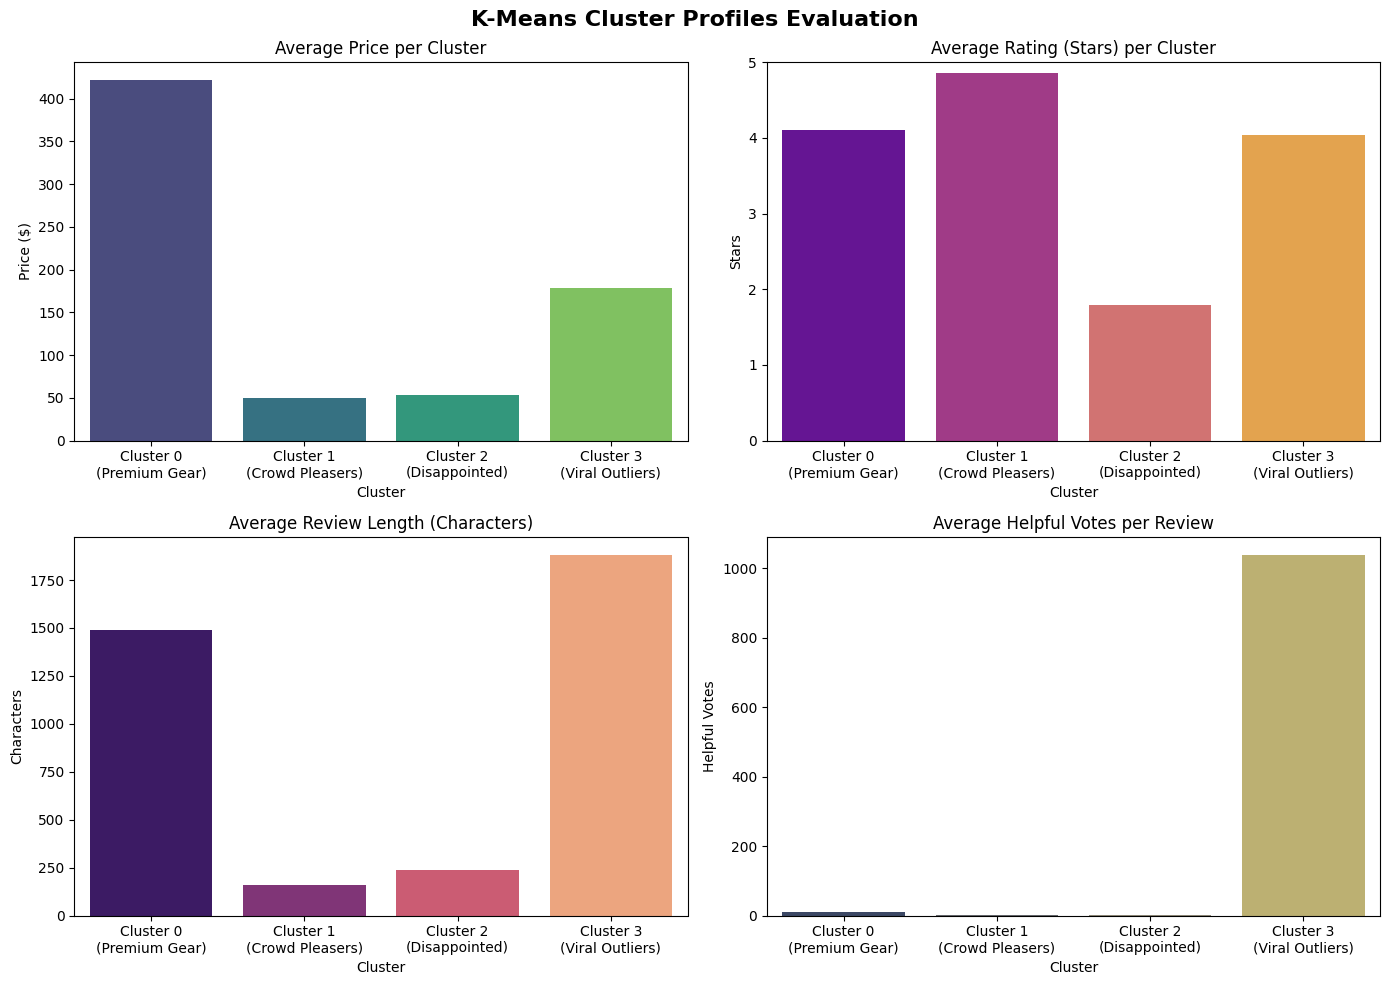

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Recreate the summary dataframe from your model output
cluster_data = {
    'Cluster': ['Cluster 0\n(Premium Gear)', 'Cluster 1\n(Crowd Pleasers)', 'Cluster 2\n(Disappointed)', 'Cluster 3\n(Viral Outliers)'],
    'Price ($)': [421.47, 49.25, 52.94, 178.87],
    'Rating (Stars)': [4.10, 4.86, 1.79, 4.04],
    'Review Length': [1488.70, 160.03, 239.15, 1878.77],
    'Helpful Votes': [10.20, 0.56, 1.12, 1037.12],
    'Total Volume': [10648, 264338, 68738, 26]
}
df_metrics = pd.DataFrame(cluster_data)

# 2. Set up a 2x2 grid to see all dimensions simultaneously
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('K-Means Cluster Profiles Evaluation', fontsize=16, fontweight='bold')

# Chart 1: Average Price
sns.barplot(x='Cluster', y='Price ($)', data=df_metrics, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Average Price per Cluster')
axes[0,0].set_ylabel('Price ($)')

# Chart 2: Average Rating
sns.barplot(x='Cluster', y='Rating (Stars)', data=df_metrics, ax=axes[0,1], palette='plasma')
axes[0,1].set_title('Average Rating (Stars) per Cluster')
axes[0,1].set_ylabel('Stars')
axes[0,1].set_ylim(0, 5)

# Chart 3: Review Length
sns.barplot(x='Cluster', y='Review Length', data=df_metrics, ax=axes[1,0], palette='magma')
axes[1,0].set_title('Average Review Length (Characters)')
axes[1,0].set_ylabel('Characters')

# Chart 4: Helpful Votes
sns.barplot(x='Cluster', y='Helpful Votes', data=df_metrics, ax=axes[1,1], palette='cividis')
axes[1,1].set_title('Average Helpful Votes per Review')
axes[1,1].set_ylabel('Helpful Votes')

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Load your perfectly balanced dataset
file_path = "/Volumes/T7 Shield/data-project/parquet/balanced_amazon_reviews_500k.parquet"
print("Loading data...")
df = pd.read_parquet(file_path)

# 2. Define what "Viral" means (Our Target)
# If a review has > 5 helpful votes, it's a 1 (Viral). Otherwise, 0.
df['is_viral'] = (df['helpful_vote'] > 5).astype(int)

# 3. Select the features the AI will learn from
features = ['price', 'rating', 'review_length']
df_ml = df.dropna(subset=features).copy()

X = df_ml[features]
y = df_ml['is_viral']

# 4. Train the Random Forest Model
print("Training the Predictive Model...")
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X, y)

# 5. The Magic Step: Score the entire dataset
# predict_proba gives us the exact percentage chance of going viral
print("Generating AI Predictions for Tableau...")
df_ml['ml_viral_probability'] = model.predict_proba(X)[:, 1] # Grabs the probability of "1"

# 6. Save the AI-Scored dataset for Tableau
output_path = "/Volumes/T7 Shield/data-project/parquet/amazon_ai_scored.csv"
df_ml.to_csv(output_path, index=False)
print(f"Success! AI-Scored data saved to: {output_path}")

Loading data...
Training the Predictive Model...
Generating AI Predictions for Tableau...
Success! AI-Scored data saved to: /Volumes/T7 Shield/data-project/parquet/amazon_ai_scored.csv
